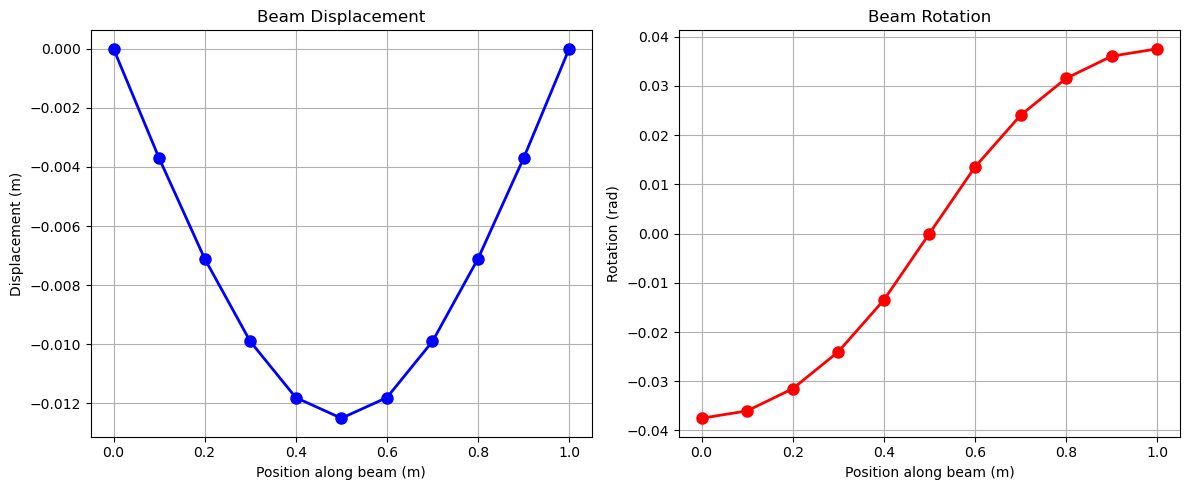

Euler-Bernoulli Beam FEM Analysis Results
Number of elements: 10
Number of nodes: 11
Beam length: 1.0 m
Bending stiffness (EI): 1.67e+03 N.m²

Nodal displacements (m):
  Node 0: x = 0.000 m -> w = 0.000000e+00 m
  Node 1: x = 0.100 m -> w = -3.701481e-03 m
  Node 2: x = 0.200 m -> w = -7.102841e-03 m
  Node 3: x = 0.300 m -> w = -9.903962e-03 m
  Node 4: x = 0.400 m -> w = -1.180472e-02 m
  Node 5: x = 0.500 m -> w = -1.250500e-02 m
  Node 6: x = 0.600 m -> w = -1.180472e-02 m
  Node 7: x = 0.700 m -> w = -9.903962e-03 m
  Node 8: x = 0.800 m -> w = -7.102841e-03 m
  Node 9: x = 0.900 m -> w = -3.701481e-03 m
  Node 10: x = 1.000 m -> w = 0.000000e+00 m

Maximum displacement: 1.250500e-02 m


In [1]:
import numpy as np
import matplotlib.pyplot as plt

L = 1.0
E = 200e9
I = 8.33e-9
EI = E * I

num_elements = 10
num_nodes = num_elements + 1
node_coords = np.linspace(0, L, num_nodes)
element_length = L / num_elements

def beam_element_stiffness(EI, le):
    k = (EI / le**3) * np.array([
        [12,   6*le,  -12,   6*le],
        [6*le, 4*le**2, -6*le, 2*le**2],
        [-12,  -6*le,  12,   -6*le],
        [6*le, 2*le**2, -6*le, 4*le**2]
    ])
    return k

ndof = 2 * num_nodes
K_global = np.zeros((ndof, ndof))

for e in range(num_elements):
    node1 = e
    node2 = e + 1
    dof_indices = [2*node1, 2*node1+1, 2*node2, 2*node2+1]
    k_elem = beam_element_stiffness(EI, element_length)
    for i, dof_i in enumerate(dof_indices):
        for j, dof_j in enumerate(dof_indices):
            K_global[dof_i, dof_j] += k_elem[i, j]

fixed_dofs = [0, 2*num_nodes - 2]
free_dofs = [i for i in range(ndof) if i not in fixed_dofs]
K_reduced = K_global[np.ix_(free_dofs, free_dofs)]

F_global = np.zeros(ndof)
mid_node = num_nodes // 2
F_global[2*mid_node] = -1000.0

F_reduced = F_global[free_dofs]

U_reduced = np.linalg.solve(K_reduced, F_reduced)

U = np.zeros(ndof)
U[free_dofs] = U_reduced

displacements = U[0::2]
rotations = U[1::2]

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(node_coords, displacements, 'bo-', linewidth=2, markersize=8)
plt.xlabel('Position along beam (m)')
plt.ylabel('Displacement (m)')
plt.title('Beam Displacement')
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(node_coords, rotations, 'ro-', linewidth=2, markersize=8)
plt.xlabel('Position along beam (m)')
plt.ylabel('Rotation (rad)')
plt.title('Beam Rotation')
plt.grid(True)

plt.tight_layout()
plt.show()

print("=" * 50)
print("Euler-Bernoulli Beam FEM Analysis Results")
print("=" * 50)
print(f"Number of elements: {num_elements}")
print(f"Number of nodes: {num_nodes}")
print(f"Beam length: {L} m")
print(f"Bending stiffness (EI): {EI:.2e} N.m²")
print("\nNodal displacements (m):")
for i, (x, w) in enumerate(zip(node_coords, displacements)):
    print(f"  Node {i}: x = {x:.3f} m -> w = {w:.6e} m")
print(f"\nMaximum displacement: {np.max(np.abs(displacements)):.6e} m")
print("=" * 50)